
[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Correlation Matrix:
Ticker       Cocoa  Crude Oil  Cotton  Gold  Copper  Coffee  Natural Gas  \
Ticker                                                                     
Cocoa         1.00       0.03    0.04  0.06    0.05    0.15        -0.01   
Crude Oil     0.03       1.00    0.05  0.03    0.10    0.06         0.01   
Cotton        0.04       0.05    1.00  0.08    0.21    0.11         0.05   
Gold          0.06       0.03    0.08  1.00    0.30    0.11         0.02   
Copper        0.05       0.10    0.21  0.30    1.00    0.16         0.01   
Coffee        0.15       0.06    0.11  0.11    0.16    1.00         0.04   
Natural Gas  -0.01       0.01    0.05  0.02    0.01    0.04         1.00   
Sugar         0.08       0.12    0.14  0.07    0.11    0.19         0.01   
Silver        0.07       0.04    0.13  0.78    0.42    0.13         0.02   
Corn         -0.01       0.10  

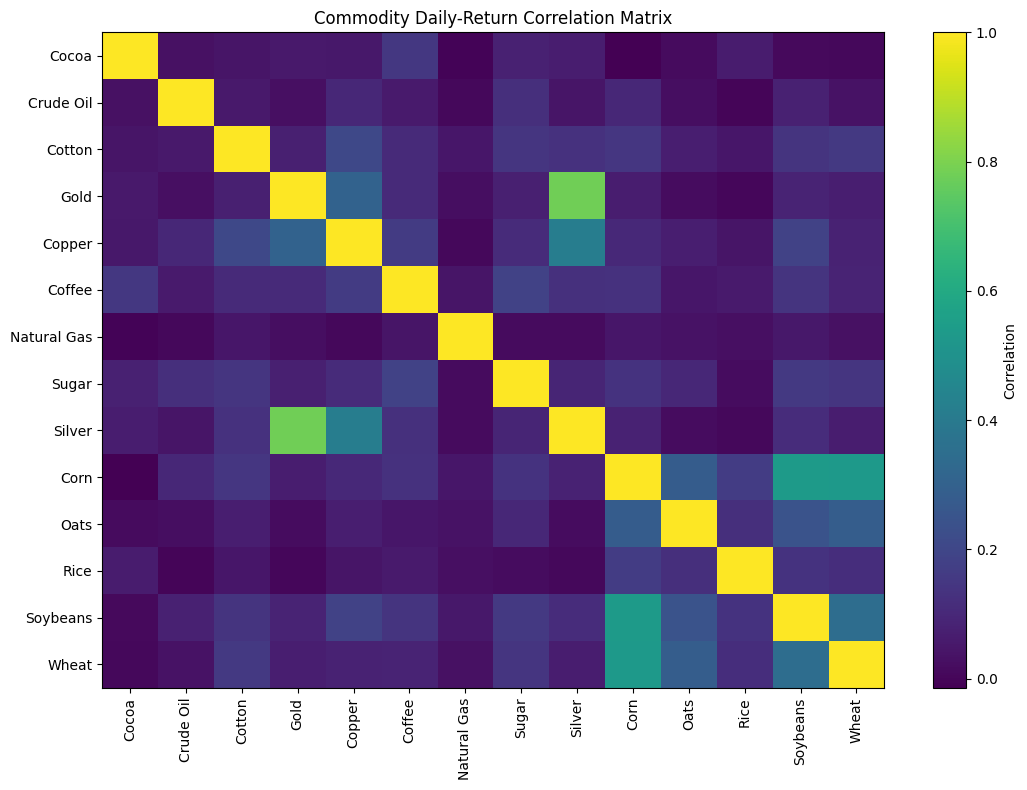

In [3]:
!pip install yfinance pandas matplotlib statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Commodities to compare
tickers = {
    "Corn": "ZC=F",
    "Wheat": "ZW=F",
    "Soybeans": "ZS=F",
    "Oats": "ZO=F",
    "Rice": "ZR=F",
    "Coffee": "KC=F",
    "Cocoa": "CC=F",
    "Sugar": "SB=F",
    "Cotton": "CT=F",
    "Crude Oil": "CL=F",
    "Natural Gas": "NG=F",
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Copper": "HG=F"
}

# Download 10 years of daily data
data = yf.download(
    list(tickers.values()),
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Extract closing prices and rename columns
prices = data["Close"]
prices = prices.rename(columns={symbol: name for name, symbol in tickers.items()})
prices = prices.dropna(axis=1, how="all")

# Calculate daily returns
returns = prices.pct_change(fill_method=None)

# Correlation matrix
correlation_matrix = returns.corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

# Find the most highly correlated pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

top_pairs = upper_triangle.stack().sort_values(ascending=False)

print("\nTop 10 Most Correlated Pairs:")
print(top_pairs.head(10))

# Save files
prices.to_csv("commodity_prices.csv")
returns.to_csv("commodity_returns.csv")
correlation_matrix.to_csv("commodity_correlation_matrix.csv")

# Display correlation heatmap
plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)),
           correlation_matrix.index)
plt.title("Commodity Daily-Return Correlation Matrix")
plt.tight_layout()
plt.show()

### Cointegration Test

Correlation only says prices move together day-to-day. Cointegration asks whether the *spread* is mean-reverting — which is what pairs trading needs. We screen every commodity pair with the Engle-Granger test on log prices; look for low p-values (ideally < 0.05).

In [4]:
# Cointegration is the right test for pairs trading:
# high correlation ≠ mean-reverting spread. We need a stationary residual.
from itertools import combinations
from statsmodels.tsa.stattools import coint

# Use log prices (standard for Engle-Granger cointegration)
log_prices = np.log(prices)

results = []
for a, b in combinations(log_prices.columns, 2):
    pair = log_prices[[a, b]].dropna()
    if len(pair) < 252:  # need enough history
        continue
    t_stat, p_value, crit = coint(pair[a], pair[b])
    corr = returns[[a, b]].corr().iloc[0, 1]
    results.append({
        "Pair": f"{a} / {b}",
        "P-value": p_value,
        "T-stat": t_stat,
        "Corr": corr,
        "N": len(pair),
    })

coint_results = (
    pd.DataFrame(results)
    .sort_values("P-value")
    .reset_index(drop=True)
)

print("All pairs ranked by cointegration p-value (lower = stronger evidence):")
print(coint_results.round(4).to_string(index=False))

print("\nCandidates with p < 0.05:")
sig = coint_results[coint_results["P-value"] < 0.05]
print(sig.round(4).to_string(index=False) if len(sig) else "None found at 5% significance.")

# Keep the best pair for the next step (spread / z-score trading)
best = coint_results.iloc[0]
print(f"\nBest candidate: {best['Pair']} (p={best['P-value']:.4f}, corr={best['Corr']:.3f})")
best_a, best_b = [s.strip() for s in best["Pair"].split("/")]
selected_pair = log_prices[[best_a, best_b]].dropna()


/Users/adamqattan/Downloads/MMF Operations Research/.venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


All pairs ranked by cointegration p-value (lower = stronger evidence):
                   Pair  P-value  T-stat    Corr    N
           Oats / Wheat   0.0017 -4.4134  0.2845 2512
           Corn / Wheat   0.0035 -4.2135  0.5287 2510
      Crude Oil / Wheat   0.0107 -3.8766  0.0356 2511
Crude Oil / Natural Gas   0.0109 -3.8695  0.0075 2512
        Corn / Soybeans   0.0129 -3.8159  0.5400 2510
   Crude Oil / Soybeans   0.0205 -3.6616  0.0793 2511
       Crude Oil / Corn   0.0223 -3.6329  0.0997 2509
     Natural Gas / Corn   0.0263 -3.5744  0.0460 2510
     Crude Oil / Coffee   0.0265 -3.5719  0.0591 2512
          Cotton / Corn   0.0283 -3.5490  0.1448 2510
   Cotton / Natural Gas   0.0298 -3.5303  0.0475 2514
         Cotton / Wheat   0.0301 -3.5272  0.1559 2512
      Cotton / Soybeans   0.0304 -3.5230  0.1384 2512
       Soybeans / Wheat   0.0304 -3.5229  0.3472 2512
          Cotton / Oats   0.0312 -3.5132  0.0702 2512
     Natural Gas / Oats   0.0448 -3.3781  0.0336 2512
        Cop